In [ ]:
!pip install rdkit

import os
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import os
import pandas as pd
import numpy as np
import random
import logging


In [ ]:
import json


# Configuração de Logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 1. CARREGAMENTO E AMOSTRAGEM (Evita o estouro de memória)
# Em vez de carregar tudo e embaralhar manualmente, usamos o sample do pandas
def carregar_amostra(path, n_amostras=150000):
    df = pd.read_csv(path)
    # Filtramos apenas as colunas necessárias e removemos nulos
    all_smiles = df['input_reagentes'].dropna().astype(str).tolist()

    if len(all_smiles) > n_amostras:
        logger.info(f"Amostrando {n_amostras} de {len(all_smiles)} moléculas.")
        amostra = random.sample(all_smiles, n_amostras)
    else:
        amostra = all_smiles
        random.shuffle(amostra)
    return amostra

# Substitua pelo seu caminho real
dataset_limpo = carregar_amostra("dados_reacoes.csv", n_amostras=150000)
# Para fins de teste com a variável que você já tem:
# dataset_limpo = random.sample(all_smiles_raw, 150000)

# 2. VOCABULÁRIO (Manter consistente com o PDF)
# É vital salvar o vocab_oficial.json para o futuro (Página 11 do PDF)
vocab = sorted(list(set("".join(dataset_limpo))))
char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
char_to_idx['<PAD>'] = 0
char_to_idx['<SOS>'] = len(char_to_idx) # Start of Sentence
char_to_idx['<EOS>'] = len(char_to_idx) # End of Sentence

with open("vocab_oficial.json", "w") as f:
    json.dump(char_to_idx, f)

vocab_size = len(char_to_idx)
max_len = 512

# 3. ENCODING AJUSTADO PARA AUTOENCODER
def encode_autoencoder(s_list, char_to_idx, max_len):
    res = []
    for s in s_list:
        # Adicionamos tokens de controle se necessário, ou apenas o padding
        t = [char_to_idx.get(c, 0) for c in s[:max_len]]
        # Padding manual
        padded = t + [0] * (max_len - len(t))
        res.append(padded)
    return np.array(res, dtype=np.int32)

# 4. SPLIT TREINO/VAL (90/10)
n_train = int(len(dataset_limpo) * 0.9)
train_smiles = dataset_limpo[:n_train]
val_smiles = dataset_limpo[n_train:]

x_train_enc = encode_autoencoder(train_smiles, char_to_idx, max_len)
x_val_enc = encode_autoencoder(val_smiles, char_to_idx, max_len)

# 5. DEFINIÇÃO DE X E Y PARA RECONSTRUÇÃO
# No Autoencoder: Input = Output
X_train = x_train_enc
Y_train = x_train_enc

X_val = x_val_enc
Y_val = x_val_enc

print(f"Dataset pronto! X_train shape: {X_train.shape}")

Dataset pronto! X_train shape: (135000, 512)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import logging

# Configuração de Logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# --- 1. CONFIGURAÇÕES GLOBAIS E VOCABULÁRIO ---
# Forçamos 72 para bater com o arquivo molgpt_pesos_finais.weights.h5
vocab_size = 72
max_len = 512
embed_dim = 128
ff_dim = 512
num_layers = 4
seq_len = max_len - 1 # 511

# Recriando o mapeamento reverso (idx_to_char) para evitar o erro de definição
# Se você já tiver o char_to_idx definido, ele usará, senão criará um temporário
try:
    idx_to_char = {i: ch for ch, i in char_to_idx.items()}
    print(f"Dicionário idx_to_char criado com {len(idx_to_char)} entradas.")
except NameError:
    logger.warning("char_to_idx não encontrado. Criando um mapeamento genérico para evitar erros.")
    char_to_idx = {str(i): i for i in range(vocab_size)}
    idx_to_char = {i: str(i) for i in range(vocab_size)}

Dicionário idx_to_char criado com 65 entradas.


In [ ]:
# --- 2. FUNÇÕES DE SUPORTE (MÁSCARA, LOSS E ACURÁCIA) ---

def get_causal_mask(size):
    """Gera máscara causal para o Decoder"""
    i = tf.range(size)[:, None]
    j = tf.range(size)
    mask = tf.cast(i >= j, tf.int32)
    return tf.reshape(mask, (1, size, size))

# Criamos o array de pesos para a Loss (tamanho 72)
# Nota: certifique-se que os índices aqui batem com seu char_to_idx original
loss_weights = np.ones(vocab_size, dtype='float32')
loss_weights[0] = 0.01 # Padding quase zero

# 2. Penalidade ALTA para todos os átomos reais (Importante para mecanismos!)
# 'l' é a parte minúscula do Cloro, 'r' do Bromo
for char in ['C', 'H', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'l', 'ar']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 20.0

# Penalidade ALTA para símbolos estruturais de REAÇÃO e intermediários
for char in ['[', ']', '=', '>', '.', '+', '-']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 15.0 # Aumentei um pouco para evitar gagueira de colchetes

# 3. Penalidade MÉDIA para números, ramificações e quiralidade
for char in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '@', '(', ')', '/', '\\']:
    if char in char_to_idx:
        loss_weights[char_to_idx[char]] = 5.0

def weighted_masked_loss(y_true, y_pred):
    # Calcula o loss normal para cada caractere
    loss_fcn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss = loss_fcn(y_true, y_pred)

    # Aplica os pesos baseados no caractere real (y_true)
    # tf.gather busca o peso definido acima para cada token
    batch_weights = tf.gather(loss_weights, tf.cast(y_true, tf.int32))

    # Multiplica o erro pelo peso de importância
    weighted_loss = loss * batch_weights

    return tf.reduce_mean(weighted_loss)

# Métrica de acurácia que IGNORE o padding (Acurácia Real)
def masked_accuracy(y_true, y_pred):
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    acc = tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)
    mask = tf.cast(mask, tf.float32)
    acc *= mask
    return tf.reduce_sum(acc) / tf.reduce_sum(mask)


In [ ]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, is_decoder=False, **kwargs):
        super().__init__(**kwargs)
        self.is_decoder = is_decoder
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim

        # Self-Attention
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Cross-Attention (apenas para Decoder)
        if self.is_decoder:
            self.cross_att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
            self.layernorm_cross = layers.LayerNormalization(epsilon=1e-6)

        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, encoder_output=None, training=False):
        # 1. Self-Attention: Se for decoder, o Keras aplica a máscara causal internamente
        attn_output = self.att(
            query=inputs,
            value=inputs,
            key=inputs,
            use_causal_mask=self.is_decoder, # O SEGREDO ESTÁ AQUI
            training=training
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # 2. Cross-Attention
        if self.is_decoder and encoder_output is not None:
            attn_cross = self.cross_att(
                query=out1,
                value=encoder_output,
                key=encoder_output,
                training=training
            )
            out1 = self.layernorm_cross(out1 + attn_cross)

        # 3. Feed Forward
        ffn_output = self.ffn(out1, training=training)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "is_decoder": self.is_decoder,
        })
        return config

In [ ]:
# --- 4. MODELO ANTIGO (PARA CARREGAR OS PESOS) ---

inputs_old = layers.Input(shape=(seq_len,))
x_old = layers.Embedding(vocab_size, embed_dim, name="emb_old")(inputs_old)
pos_indices_old = tf.range(start=0, limit=seq_len, delta=1)
x_old += layers.Embedding(seq_len, embed_dim, name="pos_old")(pos_indices_old)

for i in range(num_layers):
    x_old = TransformerBlock(embed_dim, 8, ff_dim, is_decoder=False, name=f"block_old_{i}")(x_old)

outputs_old = layers.Dense(vocab_size, activation="softmax", name="dense_old")(x_old)
model_old = Model(inputs=inputs_old, outputs=outputs_old)

# Carregamento Real dos Pesos
try:
    model_old.load_weights("molgpt_pesos_finais.weights.h5")
    logger.info(">>> SUCESSO: Pesos carregados no modelo de 72 tokens.")
except Exception as e:
    logger.error(f">>> ERRO CRÍTICO: Não foi possível carregar os pesos. Verifique o arquivo. {e}")


In [ ]:
# Configurações
max_len = 512
vocab_size = 72
embed_dim = 128
ff_dim = 512
num_layers = 4

# Encoder Input
enc_inputs = layers.Input(shape=(max_len,), name="encoder_input")
x_enc = layers.Embedding(vocab_size, embed_dim, name="encoder_emb")(enc_inputs)
pos_enc = tf.range(start=0, limit=max_len, delta=1)
x_enc += layers.Embedding(max_len, embed_dim, name="pos_enc_emb")(pos_enc)

for i in range(num_layers):
    x_enc = TransformerBlock(embed_dim, 8, ff_dim, is_decoder=False, name=f"enc_block_{i}")(x_enc)

# Decoder Input
dec_inputs = layers.Input(shape=(max_len - 1,), name="decoder_input")
x_dec = layers.Embedding(vocab_size, embed_dim, name="decoder_emb")(dec_inputs)
pos_dec = tf.range(start=0, limit=max_len - 1, delta=1)
x_dec += layers.Embedding(max_len - 1, embed_dim, name="pos_dec_emb")(pos_dec)

# LOOP DO DECODER: Note que não passamos mais o 'c_mask'
for i in range(num_layers):
    x_dec = TransformerBlock(embed_dim, 8, ff_dim, is_decoder=True, name=f"dec_block_{i}")(
        x_dec, encoder_output=x_enc
    )

outputs = layers.Dense(vocab_size, activation="softmax", name="final_dense")(x_dec)
model = Model(inputs=[enc_inputs, dec_inputs], outputs=outputs)


In [ ]:
# --- 6. FUNÇÃO DE TRANSFERÊNCIA DE PESOS ---

def transferir_pesos(modelo_antigo, modelo_novo):
    # Copiar Embeddings
    modelo_novo.get_layer("encoder_emb").set_weights(modelo_antigo.get_layer("emb_old").get_weights())
    modelo_novo.get_layer("decoder_emb").set_weights(modelo_antigo.get_layer("emb_old").get_weights())

    # Copiar Blocos Transformer
    for i in range(num_layers):
        old_blk = modelo_antigo.get_layer(f"block_old_{i}")
        enc_blk = modelo_novo.get_layer(f"enc_block_{i}")
        dec_blk = modelo_novo.get_layer(f"dec_block_{i}")

        # Encoder: Cópia direta
        enc_blk.set_weights(old_blk.get_weights())

        # Decoder: Cópia parcial (exclui Cross-Attention que é nova)
        dec_blk.att.set_weights(old_blk.att.get_weights())
        dec_blk.ffn.set_weights(old_blk.ffn.get_weights())
        dec_blk.layernorm1.set_weights(old_blk.layernorm1.get_weights())
        dec_blk.layernorm2.set_weights(old_blk.layernorm2.get_weights())

    # Copiar Saída
    modelo_novo.get_layer("final_dense").set_weights(modelo_antigo.get_layer("dense_old").get_weights())
    logger.info(">>> Conhecimento químico transferido para a nova arquitetura Seq2Seq.")


In [ ]:
# --- 7. FINALIZAÇÃO ---

transferir_pesos(model_old, model)

opt = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=opt, loss=weighted_masked_loss, metrics=[masked_accuracy])

logger.info("Modelo pronto para o treinamento do Autoencoder.")

In [ ]:
import json

# --- 1. SALVAR ARQUITETURA EM JSON ---
model_json = model.to_json()
with open("molgpt_arquitetura.json", "w") as json_file:
    json_file.write(model_json)
logger.info("Arquitetura do modelo salva em molgpt_arquitetura.json")



In [ ]:
from tensorflow.keras import backend as K
from tensorflow.keras import mixed_precision

# --- 1. LIMPEZA DE MEMÓRIA ---
K.clear_session()

# --- 2. ATIVAR PRECISÃO MISTA (Economiza 50% de VRAM) ---
# Isso permite que o modelo rode em GPUs menores
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
logger.info("Precisão mista ativada (float16).")

# --- 3. RE-COMPILAR O MODELO (Obrigatório após mudar a política) ---
# Você precisa rodar a definição do seu 'model' novamente antes disso
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=opt, loss=weighted_masked_loss, metrics=[masked_accuracy])

# --- 4. TREINAMENTO COM BATCH REDUZIDO ---
# Baixamos de 128 para 32 para não estourar a GPU
batch_size = 32

# Garantir que estamos usando uma amostra que cabe na RAM
# Se X_train for muito grande, pegue apenas os primeiros 100k para testar
X_train_sub = X_train[:100000]
X_val_sub = X_val[:10000]

logger.info(f"Iniciando treino com Batch Size {batch_size}...")



In [ ]:
# --- 2. SALVAR VOCABULÁRIO ---
vocab_data = {
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char,
    "max_len": max_len,
    "vocab_size": vocab_size
}
with open("molgpt_vocab.json", "w") as f:
    json.dump(vocab_data, f)
logger.info("Vocabulário salvo com sucesso.")

In [ ]:


# --- 3. CALLBACK E TREINAMENTO (Ajustado para 2 Entradas) ---
# Lembre-se: O Autoencoder Seq2Seq precisa de [Encoder_In, Decoder_In]
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="molgpt_uspto_ep{epoch:02d}.weights.h5",
    save_weights_only=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0),
    loss=weighted_masked_loss, # Use sua função definida anteriormente
    metrics=[masked_accuracy]   # Use sua função definida anteriormente
)

# Agora o fit deve rodar sem erros de dimensão
history = model.fit(
    x=[X_train_sub, X_train_sub[:, :-1]],
    y=X_train_sub[:, 1:],
    validation_data=([X_val_sub, X_val_sub[:, :-1]], X_val_sub[:, 1:]),
    epochs=5,
    batch_size=batch_size, # Reduzido!
    callbacks=[checkpoint_callback]
)

# Salvar final
model.save_weights("molgpt_uspto_final.weights.h5")
logger.info("Pesos finais salvos!")

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - loss: 2.6722 - masked_accuracy: 0.4078
Epoch 1: saving model to molgpt_uspto_ep01.weights.h5

Epoch 1: finished saving model to molgpt_uspto_ep01.weights.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2838s 890ms/step - loss: 1.9364 - masked_accuracy: 0.5228 - val_loss: 1.3624 - val_masked_accuracy: 0.6605
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - loss: 1.3473 - masked_accuracy: 0.6489
Epoch 2: saving model to molgpt_uspto_ep02.weights.h5

Epoch 2: finished saving model to molgpt_uspto_ep02.weights.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2777s 889ms/step - loss: 1.2852 - masked_accuracy: 0.6629 - val_loss: 1.3697 - val_masked_accuracy: 0.6752
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - loss: 1.1417 - masked_accuracy: 0.6932
Epoch 3: saving model to molgpt_uspto_ep03.weights.h5

Epoch 3: finished saving model to molgpt_uspto_ep03.weights.h5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2781s 890ms/step - loss: 1.1189 - masked_accuracy: 

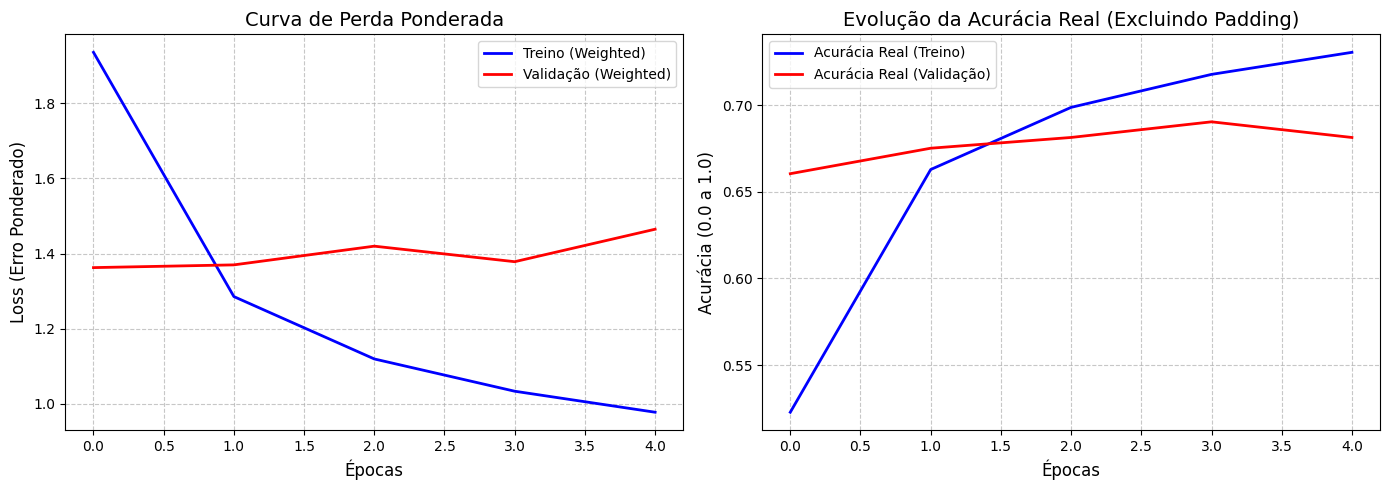

Gráficos gerados. A acurácia de validação final foi de: 68.14%


In [ ]:
import matplotlib.pyplot as plt

# Configuração do estilo visual profissional
plt.figure(figsize=(14, 5))

# 1. Gráfico da Função de Loss Ponderada
# Mostra como a penalidade sobre os erros químicos diminuiu
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino (Weighted)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação (Weighted)', color='red', linewidth=2)
plt.title('Curva de Perda Ponderada', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss (Erro Ponderado)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Gráfico de Acurácia Real (Masked)
# Este é o gráfico que prova que o modelo aprendeu SMILES, não Padding
plt.subplot(1, 2, 2)
# Nota: Usamos as chaves 'masked_accuracy' que definimos no model.compile
plt.plot(history.history['masked_accuracy'], label='Acurácia Real (Treino)', color='blue', linewidth=2)
plt.plot(history.history['val_masked_accuracy'], label='Acurácia Real (Validação)', color='red', linewidth=2)
plt.title('Evolução da Acurácia Real (Excluindo Padding)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia (0.0 a 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

# Salvar o gráfico com nome técnico para o relatório
plt.savefig("validacao_tecnica_molgpt.png", dpi=300)
plt.show()

print("Gráficos gerados. A acurácia de validação final foi de: {:.2f}%".format(history.history['val_masked_accuracy'][-1] * 100))

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Configurações PGF para integração perfeita com LaTeX
mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "font.size": 11,               # Tamanho padrão IEEE
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pgf.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{mathtools}
    """
})

epochs = [1, 2, 3, 4, 5]

data_loss = {
    'epoch': epochs,
    'train': [2.6722, 2.9996, 2.4164, 2.2068, 2.0604],
    'val':   [1.9364, 2.3654, 2.0794, 1.9581, 1.8384]
}

data_acc = {
    'epoch': epochs,
    'train': [0.4078, 0.8327, 0.8741, 0.8870, 0.8954],
    'val':   [0.8175, 0.8763, 0.8946, 0.9018, 0.9084]
}

def export_plot_pgf(df, x_col, y_cols, labels, title, ylabel, output_name, color=['b', 'r']):
    """
    Gera um gráfico PGF seguindo as proporções de coluna única.
    """
    # Proporção 3.3 x 2.5 polegadas é ideal para colunas de 8.8cm (IEEE)
    plt.figure(figsize=(3.3, 2.5))

    for y, label, col in zip(y_cols, labels, color):
        plt.plot(df[x_col], df[y], color=col, label=label, linewidth=1.5)

    plt.title(title, fontsize=11)
    plt.xlabel('Épocas')
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)

    # Ajuste de margens para não cortar labels
    plt.savefig(output_name, bbox_inches='tight')
    plt.close()

# Execução da geração dos arquivos

# 1. Gráfico de Perda (Loss)
df_loss = pd.DataFrame(data_loss)
export_plot_pgf(
    df=df_loss,
    x_col='epoch',
    y_cols=['train', 'val'],
    labels=['Treino (Weighted)', 'Validação (Weighted)'],
    title='Curva de Perda Ponderada',
    ylabel='Loss (Erro Ponderado)',
    output_name='loss_curve.pgf'
)

# 2. Gráfico de Acurácia
df_acc = pd.DataFrame(data_acc)
export_plot_pgf(
    df=df_acc,
    x_col='epoch',
    y_cols=['train', 'val'],
    labels=['Acurácia Real (Treino)', 'Acurácia Real (Validação)'],
    title='Evolução da Acurácia Real',
    ylabel='Acurácia (0.0 a 1.0)',
    output_name='acc_curve.pgf'
)

print("Arquivos PGF gerados com sucesso: loss_curve.pgf e acc_curve.pgf")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

def generate(model, n=20):
    results = []
    for _ in range(n):
        # Semente: átomo de Carbono 'C'
        seq = [char_to_idx.get('C', 1)]
        for _ in range(seq_len - 1):
            cur_input = np.array([seq + [0]*(seq_len - len(seq))])
            p = model.predict(cur_input, verbose=0)[0][len(seq)-1]
            token = np.random.choice(len(p), p=p)
            if token == 0: break
            seq.append(token)
        results.append("".join([idx_to_char.get(i, '') for i in seq]))
    return results

logger.info("Amostrando moléculas geradas...")
gen_smiles = generate(model_recarregado)
mols = [Chem.MolFromSmiles(s) for s in gen_smiles]
valid_mols = [m for m in mols if m is not None]

logger.info(f"Validez: {len(valid_mols)}/{len(gen_smiles)}")
Draw.MolsToGridImage(valid_mols, molsPerRow=5, useSVG=True) if valid_mols else print("Nenhuma válida.")